# 0.0. Configure

In [27]:
from dotenv import load_dotenv

In [28]:
load_dotenv()

True

# 1.0. Imports

In [29]:
from typing import Annotated, Literal

from IPython.display import Image, display
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_experimental.utilities import PythonREPL
from langgraph.types import Command

# 2.0. Hands-On

In [30]:
ddgo_tool = DuckDuckGoSearchResults(max_results=3)

ddgo_tool.invoke("LLM Multi Agent")

'snippet: This paper presents a comprehensive and systematic review of LLM-based multi-agent systems, which are agent-based intelligent systems that leverage the reasoning and planning capabilities of large language models. It introduces a unified framework of five key modules: profile, perception, self-action, mutual interaction, and evolution, and discusses the applications and challenges of this field., title: A survey on LLM-based multi-agent systems: workflow ... - Springer, link: https://link.springer.com/article/10.1007/s44336-024-00009-2, snippet: An LLM-Based Multi Agent System consists of multiple agents that work together to achieve a common goal. Each agent in the system has a specific role and specialized in performing a particular task., title: Understanding LLM-Based Agents and their Multi-Agent Architecture, link: https://medium.com/@pallavisinha12/understanding-llm-based-agents-and-their-multi-agent-architecture-299cf54ebae4, snippet: 🚀 Jan. 16, 2024: Our paper MetaGPT

In [31]:
python_tool = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = python_tool.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"

    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"

    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [32]:
python_repl_tool("print('Hello, World!')")

"Successfully executed:\n\\`\\`\\`python\nprint('Hello, World!')\n\\`\\`\\`\nStdout: Hello, World!\n\n\nIf you have completed all tasks, respond with FINAL ANSWER."

In [33]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

In [34]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [35]:
def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto

In [36]:
research_agent = create_react_agent(
    llm,
    tools=[ddgo_tool],
    state_modifier=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ),
)

In [42]:
def research_node(state: MessagesState) -> Command[Literal["chart_generator", END]]:
    result = research_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "chart_generator")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="researcher"
    )

    return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

In [43]:
chart_agent = create_react_agent(
    llm,
    [python_repl_tool],
    state_modifier=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
)

In [44]:
def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    result = chart_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "researcher")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="chart_generator"
    )

    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

In [45]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
graph = workflow.compile()

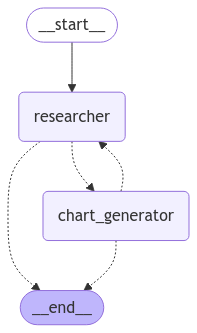

In [46]:
display(Image(graph.get_graph().draw_mermaid_png()))

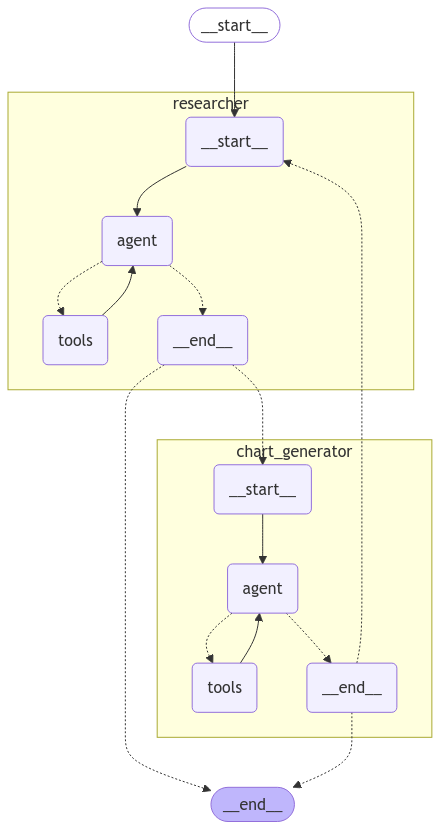

In [47]:
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

# 3.0. Testing

In [21]:
events = graph.stream(
    {
        "messages": [
            (
                "user",
                "Plot COVID cases in the US "
                "Once you make the chart, finish.",
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    print(s)
    print("----")

{'researcher': {'messages': [HumanMessage(content='Plot COVID cases in the USOnce you make the chart, finish.', additional_kwargs={}, response_metadata={}, id='b1aefde2-4ea3-43aa-9d79-e512ca66adc7'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_PBM8MzdezfRc9P6aKJV4UM5B', 'function': {'arguments': '{"query":"COVID-19 cases in the US data October 2023"}', 'name': 'duckduckgo_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 188, 'total_tokens': 218, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_72ed7ab54c', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-3bcb3ac2-7a7e-46e5-a654-600a41ac400b-0', tool_calls=[{'name': 'duckduckgo_results_json', 'args': {